<a href="https://colab.research.google.com/github/sved07/XGB-Cascade-Classifier/blob/main/idk_cascade_full_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IDK Cascade Meta-Router Study: XGBoost vs. Random Forest vs. Logistic Regression vs. Decision Tree

This notebook measures whether the **choice of meta-router** in an IDK (I-Don't-Know) cascade meaningfully affects end-to-end latency and accuracy -- and whether router overhead itself, if left unmeasured, can silently erase the benefit of cascading altogether.

Compared router families: **XGBoost**, **Random Forest**, **Logistic Regression**, and a single **Decision Tree** -- across **CIFAR-10** and **CIFAR-100**, using a ResNet20/ResNet56 (Model A / Model C) cascade pair, over 8 random seeds per dataset.

In [1]:
!pip install -q xgboost scikit-learn pandas numpy torch torchvision scipy matplotlib


In [2]:
import time
import itertools
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from scipy import stats
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using execution device: {device}")


Using execution device: cuda


## 1. Dataset and Models Setup


In [3]:
DATASETS = {
    'CIFAR-100': {
        'transform': transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5071, 0.4867, 0.4408], std=[0.2675, 0.2565, 0.2761])
        ]),
        'num_classes': 100
    },
    'CIFAR-10': {
        'transform': transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2471, 0.2435, 0.2616])
        ]),
        'num_classes': 10
    }
}

def get_dataset(dataset_name, transform):
    if dataset_name == 'CIFAR-100':
        return torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)
    elif dataset_name == 'CIFAR-10':
        return torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")

def load_models_for_dataset(dataset_name):
    if dataset_name == 'CIFAR-100':
        model_a = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar100_resnet20", pretrained=True).to(device)
        model_b = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar100_resnet32", pretrained=True).to(device)
        model_c = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar100_resnet56", pretrained=True).to(device)
    elif dataset_name == 'CIFAR-10':
        model_a = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet20", pretrained=True).to(device)
        model_b = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet32", pretrained=True).to(device)
        model_c = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet56", pretrained=True).to(device)
    model_a.eval()
    model_b.eval()
    model_c.eval()
    return model_a, model_b, model_c

transform = DATASETS['CIFAR-100']['transform']
val_dataset = get_dataset('CIFAR-100', transform)
model_a, model_b, model_c = load_models_for_dataset('CIFAR-100')
print("Base models and CIFAR-100 dataset loaded successfully.")


100%|██████████| 169M/169M [01:41<00:00, 1.66MB/s]


The repository chenyaofo_pytorch-cifar-models does not belong to the list of trusted repositories and as such cannot be downloaded. Do you trust this repository and wish to add it to the trusted list of repositories (y/N)?y
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/resnet/cifar100_resnet20-23dac2f1.pt" to /root/.cache/torch/hub/checkpoints/cifar100_resnet20-23dac2f1.pt


100%|██████████| 1.11M/1.11M [00:00<00:00, 44.6MB/s]
Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/resnet/cifar100_resnet32-84213ce6.pt" to /root/.cache/torch/hub/checkpoints/cifar100_resnet32-84213ce6.pt


100%|██████████| 1.88M/1.88M [00:00<00:00, 88.8MB/s]
Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/resnet/cifar100_resnet56-f2eff4c8.pt" to /root/.cache/torch/hub/checkpoints/cifar100_resnet56-f2eff4c8.pt


100%|██████████| 3.41M/3.41M [00:00<00:00, 115MB/s]

Base models and CIFAR-100 dataset loaded successfully.


## 2. Single-Sample Latency Profiling


In [4]:
def measure_single_sample_latency(model, single_sample, n_reps=300, n_warmup=30, device=device):
    model.eval()
    times = []
    with torch.no_grad():
        for _ in range(n_warmup):
            _ = model(single_sample)
        if device.type == "cuda":
            torch.cuda.synchronize()

        for _ in range(n_reps):
            start = time.perf_counter()
            _ = model(single_sample)
            if device.type == "cuda":
                torch.cuda.synchronize()
            end = time.perf_counter()
            times.append((end - start) * 1000)

    times = np.array(times)
    return times.mean(), times.std()

probe_batch = val_dataset[0][0].unsqueeze(0).to(device)
LATENCY_A, LATENCY_A_STD = measure_single_sample_latency(model_a, probe_batch)
LATENCY_B, LATENCY_B_STD = measure_single_sample_latency(model_b, probe_batch)
LATENCY_C, LATENCY_C_STD = measure_single_sample_latency(model_c, probe_batch)

print(f"Model A Single-Sample Latency: {LATENCY_A:.4f} +/- {LATENCY_A_STD:.4f} ms")
print(f"Model C Single-Sample Latency: {LATENCY_C:.4f} +/- {LATENCY_C_STD:.4f} ms")


Model A Single-Sample Latency: 2.5567 +/- 0.0572 ms
Model C Single-Sample Latency: 6.7495 +/- 0.3186 ms


## 3. Router Training Logic: XGBoost, Random Forest, Logistic Regression, Decision Tree

All four routers are trained on the same 3-feature telemetry (`confidence`, `entropy`, `margin`) extracted from Model A, with the same cost-sensitive class weighting so the comparison isn't confounded by one router being tuned more carefully than another. Logistic Regression and a shallow Decision Tree are included as the 'standard'/simple baselines requested alongside XGBoost and Random Forest.

In [5]:
EARLY_EXIT_THRESHOLD = 0.90

def extract_telemetry(loader, model_a, model_c, device=device):
    rows = []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs_a = model_a(images)
            probs_a = torch.softmax(outputs_a, dim=1)
            conf_A, preds_a = torch.max(probs_a, dim=1)
            entropy_A = -torch.sum(probs_a * torch.log(probs_a + 1e-6), dim=1)
            top2, _ = torch.topk(probs_a, k=2, dim=1)
            margin_A = top2[:, 0] - top2[:, 1]

            outputs_c = model_c(images)
            _, preds_c = torch.max(outputs_c, dim=1)

            actual_route_to_c = ((preds_a != labels) & (preds_c == labels)).long()

            for i in range(images.size(0)):
                rows.append({
                    'confidence': conf_A[i].item(),
                    'entropy': entropy_A[i].item(),
                    'margin': margin_A[i].item(),
                    'correct_a': (preds_a[i] == labels[i]).item(),
                    'correct_c': (preds_c[i] == labels[i]).item(),
                    'target_route': actual_route_to_c[i].item(),
                })
    return pd.DataFrame(rows)

def _cost_sensitive_pos_weight(y_train, latency_c, cost_missed_fallback=1.0):
    asymmetric_multiplier = cost_missed_fallback / max(latency_c, 1e-6)
    num_pos = np.sum(y_train == 1)
    num_neg = np.sum(y_train == 0)
    base_weight = num_neg / max(num_pos, 1)
    return base_weight * asymmetric_multiplier

def train_xgb_router(X_train, y_train, latency_c, cost_missed_fallback=1.0, seed=42):
    pos_weight = _cost_sensitive_pos_weight(y_train, latency_c, cost_missed_fallback)
    router = xgb.XGBClassifier(
        n_estimators=50, max_depth=3, learning_rate=0.1,
        scale_pos_weight=pos_weight, eval_metric='logloss', random_state=seed
    )
    router.fit(X_train, y_train)
    return router

def train_rf_router(X_train, y_train, latency_c, cost_missed_fallback=1.0, seed=42):
    pos_weight = _cost_sensitive_pos_weight(y_train, latency_c, cost_missed_fallback)
    router = RandomForestClassifier(
        n_estimators=50, max_depth=3,
        class_weight={0: 1.0, 1: pos_weight}, random_state=seed
    )
    router.fit(X_train, y_train)
    return router

def train_logreg_router(X_train, y_train, latency_c, cost_missed_fallback=1.0, seed=42):
    """'Standard model' baseline -- the simplest common router choice."""
    pos_weight = _cost_sensitive_pos_weight(y_train, latency_c, cost_missed_fallback)
    router = LogisticRegression(
        class_weight={0: 1.0, 1: pos_weight}, max_iter=1000, random_state=seed
    )
    router.fit(X_train, y_train)
    return router

def train_dtree_router(X_train, y_train, latency_c, cost_missed_fallback=1.0, seed=42):
    """Single shallow tree -- isolates whether *ensembling* itself (bagging or
    boosting) is what costs overhead, independent of tree-count."""
    pos_weight = _cost_sensitive_pos_weight(y_train, latency_c, cost_missed_fallback)
    router = DecisionTreeClassifier(
        max_depth=3, class_weight={0: 1.0, 1: pos_weight}, random_state=seed
    )
    router.fit(X_train, y_train)
    return router

# Central registry: add a new router family by adding one entry here --
# every downstream cell (overhead timing, multi-seed trial, significance
# tests, Pareto plot) iterates over this dict automatically.
ROUTER_REGISTRY = {
    'xgb':    {'label': 'XGBoost',            'train_fn': train_xgb_router,    'color': 'tab:blue',   'marker': 'o'},
    'rf':     {'label': 'Random Forest',      'train_fn': train_rf_router,     'color': 'tab:orange', 'marker': '^'},
    'logreg': {'label': 'Logistic Regression','train_fn': train_logreg_router, 'color': 'tab:purple', 'marker': 'D'},
    'dtree':  {'label': 'Decision Tree',      'train_fn': train_dtree_router,  'color': 'tab:brown',  'marker': 'P'},
}


### 3.1 Meta-Heuristic Baseline: Genetic-Algorithm-Optimized Linear Skip Rule

The four routers above are all trained ML models, each with some inference-time
call into a library (`sklearn` or `xgboost`). This section asks a different
question: can a much simpler decision rule -- optimized via a genetic algorithm
rather than gradient descent or tree-splitting -- match their accuracy while
avoiding a model-library call at inference time entirely? The resulting rule is
a linear discriminant over the same three features (confidence, entropy,
margin); at inference time it costs one dot product and one comparison.

In [6]:
# Variables and functions copied for self-containment of this cell.
# These are typically defined in earlier cells (e.g., ggZft88mKxTZ, A3M1IurBKxTZ).

# Assuming necessary imports (numpy, torch, pandas, sklearn.model_selection) are handled globally (e.g., in cell 1NYJkKsSKxTX).
# If not, add them here: `import numpy as np`, `import torch`, `import pandas as pd`, `from sklearn.model_selection import train_test_split`.

# From ggZft88mKxTZ
EARLY_EXIT_THRESHOLD = 0.90

# From ggZft88mKxTZ
def extract_telemetry(loader, model_a, model_c, device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')):
    rows = []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs_a = model_a(images)
            probs_a = torch.softmax(outputs_a, dim=1)
            conf_A, preds_a = torch.max(probs_a, dim=1)
            entropy_A = -torch.sum(probs_a * torch.log(probs_a + 1e-6), dim=1)
            top2, _ = torch.topk(probs_a, k=2, dim=1)
            margin_A = top2[:, 0] - top2[:, 1]

            outputs_c = model_c(images)
            _, preds_c = torch.max(outputs_c, dim=1)

            actual_route_to_c = ((preds_a != labels) & (preds_c == labels)).long()

            for i in range(images.size(0)):
                rows.append({
                    'confidence': conf_A[i].item(),
                    'entropy': entropy_A[i].item(),
                    'margin': margin_A[i].item(),
                    'correct_a': (preds_a[i] == labels[i]).item(),
                    'correct_c': (preds_c[i] == labels[i]).item(),
                    'target_route': actual_route_to_c[i].item(),
                })
    return pd.DataFrame(rows)

# From ggZft88mKxTZ
def _cost_sensitive_pos_weight(y_train, latency_c, cost_missed_fallback=1.0):
    asymmetric_multiplier = cost_missed_fallback / max(latency_c, 1e-6)
    num_pos = np.sum(y_train == 1)
    num_neg = np.sum(y_train == 0)
    base_weight = num_neg / max(num_pos, 1)
    return base_weight * asymmetric_multiplier

# Data preparation and splitting for X_tr and y_tr (from A3M1IurBKxTZ)
# Assuming val_dataset, model_a, model_c, LATENCY_C are defined in previous cells.
torch.manual_seed(42)
subset = torch.utils.data.Subset(val_dataset, list(range(1000)))
loader = torch.utils.data.DataLoader(subset, batch_size=32, shuffle=False)
df_probe = extract_telemetry(loader, model_a, model_c)
X_probe = df_probe[['confidence', 'entropy', 'margin']]
y_probe = df_probe['target_route']
X_tr, X_te, y_tr, y_te = train_test_split(X_probe, y_probe, test_size=0.2, random_state=42)


def _weighted_accuracy_fitness(weights, X_arr, y_arr, sample_weights):
    score = X_arr @ weights[:3] + weights[3]
    preds = (score >= 0).astype(int)
    correct = (preds == y_arr).astype(float)
    return np.sum(correct * sample_weights) / np.sum(sample_weights)

def _genetic_algorithm_search(X_arr, y_arr, sample_weights, seed=42,
                                pop_size=40, generations=60, gene_range=8.0,
                                mutation_rate=0.2, mutation_scale=0.6):
    rng = np.random.default_rng(seed)
    population = rng.uniform(-gene_range, gene_range, size=(pop_size, 4))

    def fitness_of(ind):
        return _weighted_accuracy_fitness(ind, X_arr, y_arr, sample_weights)

    best_individual, best_fitness = None, -np.inf
    for _ in range(generations):
        fitnesses = np.array([fitness_of(ind) for ind in population])
        gen_best_idx = np.argmax(fitnesses)
        if fitnesses[gen_best_idx] > best_fitness:
            best_fitness = fitnesses[gen_best_idx]
            best_individual = population[gen_best_idx].copy()

        new_population = [best_individual.copy()]  # elitism
        while len(new_population) < pop_size:
            i, j = rng.integers(0, pop_size, size=2)
            parent1 = population[i] if fitnesses[i] > fitnesses[j] else population[j]
            i, j = rng.integers(0, pop_size, size=2)
            parent2 = population[i] if fitnesses[i] > fitnesses[j] else population[j]

            mask = rng.random(4) < 0.5
            child = np.where(mask, parent1, parent2)
            mutate_mask = rng.random(4) < mutation_rate
            child = child + mutate_mask * rng.normal(0, mutation_scale, size=4)
            child = np.clip(child, -gene_range, gene_range)
            new_population.append(child)

        population = np.array(new_population[:pop_size])

    return best_individual, best_fitness


class HeuristicRouter:
    """Linear skip rule: escalate iff w.features + bias >= 0. No model-library
    call at inference time -- just a dot product and a comparison."""
    def __init__(self, weights):
        self.weights = np.asarray(weights, dtype=float)

    def predict_proba(self, X):
        X_arr = X.values if hasattr(X, 'values') else np.asarray(X)
        score = X_arr @ self.weights[:3] + self.weights[3]
        prob_escalate = 1.0 / (1.0 + np.exp(-score))
        return np.column_stack([1 - prob_escalate, prob_escalate])


def train_heuristic_router(X_train, y_train, latency_c, cost_missed_fallback=1.0, seed=42):
    """Trains the linear skip rule via a genetic algorithm, optimizing the same
    cost-weighted classification objective as the other routers."""
    pos_weight = _cost_sensitive_pos_weight(y_train, latency_c, cost_missed_fallback)
    X_arr = X_train.values if hasattr(X_train, 'values') else np.asarray(X_train)
    y_arr = y_train.values if hasattr(y_train, 'values') else np.asarray(y_train)
    sample_weights = np.where(y_arr == 1, pos_weight, 1.0)

    best_weights, _ = _genetic_algorithm_search(X_arr, y_arr, sample_weights, seed=seed)
    return HeuristicRouter(best_weights)


ROUTER_REGISTRY['heuristic'] = {
    'label': 'GA Heuristic', 'train_fn': train_heuristic_router,
    'color': 'tab:green', 'marker': 'X',
}

_heuristic_bench = train_heuristic_router(X_tr, y_tr, LATENCY_C, seed=42)
_fit = _weighted_accuracy_fitness(_heuristic_bench.weights, X_tr.values, y_tr.values,
                                    np.where(y_tr.values == 1,
                                             _cost_sensitive_pos_weight(y_tr.values, LATENCY_C), 1.0))
print(f"GA Heuristic trained. Learned weights (conf, entropy, margin, bias): {_heuristic_bench.weights}")
print(f"Weighted training accuracy: {_fit:.4f}")
print(f"Registered in ROUTER_REGISTRY: {'heuristic' in ROUTER_REGISTRY}")

GA Heuristic trained. Learned weights (conf, entropy, margin, bias): [-2.21099823 -6.30625507 -8.          7.39036263]
Weighted training accuracy: 0.8728
Registered in ROUTER_REGISTRY: True


## 4. Single-Sample Router Inference Micro-Overhead Timing

This isolates each router's *own* inference cost (the `predict_proba` call), separate from Model A/C latency. This overhead is what Section 4's `evaluate_router_cascade` folds into the end-to-end cascade latency -- without this step, the comparison silently ignores the router's own compute cost.

In [7]:
def measure_router_overhead_per_sample(router, X_test, n_reps=5):
    X_arr = X_test.values if hasattr(X_test, 'values') else X_test
    times = []
    for _ in range(n_reps):
        for row in X_arr:
            row = row.reshape(1, -1)
            start = time.perf_counter()
            _ = router.predict_proba(row)
            end = time.perf_counter()
            times.append((end - start) * 1000)
    times = np.array(times)
    return times.mean(), times.std()

# Train one sample of each router family purely to demonstrate overhead in isolation
torch.manual_seed(42)
subset = torch.utils.data.Subset(val_dataset, list(range(1000)))
loader = torch.utils.data.DataLoader(subset, batch_size=32, shuffle=False)
df_probe = extract_telemetry(loader, model_a, model_c)
X_probe = df_probe[['confidence', 'entropy', 'margin']]
y_probe = df_probe['target_route']
X_tr, X_te, y_tr, y_te = train_test_split(X_probe, y_probe, test_size=0.2, random_state=42)

print("=== Router Overhead (isolated predict_proba cost) ===")
for name, spec in ROUTER_REGISTRY.items():
    bench_router = spec['train_fn'](X_tr, y_tr, LATENCY_C, seed=42)
    mean_oh, std_oh = measure_router_overhead_per_sample(bench_router, X_te.head(200))
    spec['demo_overhead_mean'] = mean_oh
    spec['demo_overhead_std'] = std_oh
    print(f"[METRIC] {spec['label']:<20s} Overhead : {mean_oh:.5f} +/- {std_oh:.5f} ms/sample")


=== Router Overhead (isolated predict_proba cost) ===
[METRIC] XGBoost              Overhead : 0.40036 +/- 0.06360 ms/sample


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

[METRIC] Random Forest        Overhead : 3.45520 +/- 0.74301 ms/sample
[METRIC] Logistic Regression  Overhead : 0.20564 +/- 0.08073 ms/sample
[METRIC] Decision Tree        Overhead : 0.20491 +/- 0.05568 ms/sample
[METRIC] GA Heuristic         Overhead : 0.01236 +/- 0.00246 ms/sample


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist

## 5. Evaluation and Naive Baseline


In [8]:
def naive_threshold_cascade(raw_df, tau, LATENCY_A, LATENCY_C):
    route = (raw_df['confidence'] < tau).astype(int)
    latency = LATENCY_A + route * LATENCY_C
    correct = np.where(route == 1, raw_df['correct_c'], raw_df['correct_a'])
    return {
        'avg_latency': latency.mean(),
        'accuracy': correct.mean() * 100,
    }

def evaluate_router_cascade(router, X_test, raw_test, LATENCY_A, LATENCY_C, theta=0.20):
    n = len(raw_test)
    router_probs = router.predict_proba(X_test)[:, 1]
    decisions = np.where(router_probs >= theta, 1, 0)

    # NEW: measure this router's own per-sample overhead once, up front
    router_overhead_mean, _ = measure_router_overhead_per_sample(router, X_test.head(200))

    latency_total = 0.0
    correct = 0
    for i in range(n):
        latency_total += LATENCY_A + router_overhead_mean   # <- overhead now counted
        if raw_test.loc[i, 'confidence'] >= EARLY_EXIT_THRESHOLD:
            correct += raw_test.loc[i, 'correct_a']
        elif decisions[i] == 1:
            latency_total += LATENCY_C
            correct += raw_test.loc[i, 'correct_c']
        else:
            correct += raw_test.loc[i, 'correct_a']

    return {'avg_latency': latency_total / n, 'accuracy': (correct / n) * 100, 'router_overhead': router_overhead_mean}


## 6. Multi-Seed Replication: All Router Families


In [9]:
def run_seed_trial_comparison(seed, n_samples, chosen_theta, dataset_name, models, transform, latency_a, latency_c, compute_time_acc):
    torch.manual_seed(seed)
    val_dataset_current = get_dataset(dataset_name, transform)
    idx = torch.randperm(len(val_dataset_current))[:n_samples]
    subset = torch.utils.data.Subset(val_dataset_current, idx)
    loader = torch.utils.data.DataLoader(subset, batch_size=32, shuffle=False)

    model_a, _, model_c = models
    df = extract_telemetry(loader, model_a, model_c)
    X = df[['confidence', 'entropy', 'margin']]
    y = df['target_route']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
    raw_test = df.loc[X_test.index].reset_index(drop=True)
    X_test_reset = X_test.reset_index(drop=True)

    acc_expert = raw_test['correct_c'].mean() * 100
    naive_res = naive_threshold_cascade(raw_test, tau=0.80, LATENCY_A=latency_a, LATENCY_C=latency_c)

    result = {
        'dataset': dataset_name,
        'seed': seed,
        'expert_accuracy': acc_expert,
        'expert_latency': latency_c,
        'naive_accuracy': naive_res['accuracy'],
        'naive_latency': naive_res['avg_latency'],
    }

    # Train + evaluate every router in the registry, timing each family's
    # total train+eval compute so we can report per-family compute cost
    # (distinct from per-sample inference latency) alongside the final results.
    for name, spec in ROUTER_REGISTRY.items():
        t_start = time.perf_counter()
        router = spec['train_fn'](X_train, y_train, latency_c, seed=seed)
        res = evaluate_router_cascade(router, X_test_reset, raw_test, latency_a, latency_c, theta=chosen_theta)
        t_end = time.perf_counter()

        compute_time_acc[name] = compute_time_acc.get(name, 0.0) + (t_end - t_start)
        result[f'{name}_accuracy'] = res['accuracy']
        result[f'{name}_latency'] = res['avg_latency']
        result[f'{name}_overhead'] = res['router_overhead']

    return result

SEEDS = [1, 2, 3, 4, 5, 6, 7, 8]
CHOSEN_THETA = 0.20
N_SAMPLES_PER_SEED = 4000
DATASETS_TO_EVALUATE = ['CIFAR-100', 'CIFAR-10']

ROUTER_COMPUTE_TIME_SEC = {}   # accumulated train+eval time per router family, across all seeds/datasets
all_trial_results = []

PIPELINE_START = time.perf_counter()
for dataset_name in DATASETS_TO_EVALUATE:
    print(f"\n=== Running multi-router trial for dataset: {dataset_name} ===")
    current_transform = DATASETS[dataset_name]['transform']
    current_models = load_models_for_dataset(dataset_name)

    dataset_trial_results = [
        run_seed_trial_comparison(s, N_SAMPLES_PER_SEED, CHOSEN_THETA, dataset_name, current_models,
                                   current_transform, LATENCY_A, LATENCY_C, ROUTER_COMPUTE_TIME_SEC)
        for s in SEEDS
    ]
    all_trial_results.extend(dataset_trial_results)
PIPELINE_END = time.perf_counter()
TOTAL_PIPELINE_WALLCLOCK_SEC = PIPELINE_END - PIPELINE_START

trial_df = pd.DataFrame(all_trial_results)
print("\nAll multi-seed trials completed successfully.")
print(trial_df.head())



=== Running multi-router trial for dataset: CIFAR-100 ===


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fi


=== Running multi-router trial for dataset: CIFAR-10 ===


Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/resnet/cifar10_resnet20-4118986f.pt" to /root/.cache/torch/hub/checkpoints/cifar10_resnet20-4118986f.pt


...

Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/resnet/cifar10_resnet32-ef93fc4d.pt" to /root/.cache/torch/hub/checkpoints/cifar10_resnet32-ef93fc4d.pt


100%|██████████| 1.85M/1.85M [00:00<00:00, 74.2MB/s]
Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/resnet/cifar10_resnet56-187c023a.pt" to /root/.cache/torch/hub/checkpoints/cifar10_resnet56-187c023a.pt


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fi


All multi-seed trials completed successfully.
     dataset  seed  expert_accuracy  expert_latency  naive_accuracy  \
0  CIFAR-100     1           73.750        6.749499          74.625   
1  CIFAR-100     2           73.500        6.749499          72.500   
2  CIFAR-100     3           71.500        6.749499          72.875   
3  CIFAR-100     4           74.375        6.749499          74.000   
4  CIFAR-100     5           72.625        6.749499          74.125   

   naive_latency  xgb_accuracy  xgb_latency  xgb_overhead  rf_accuracy  ...  \
0       5.129911        73.375     5.098051      0.398420       73.875  ...   
1       5.231154        72.375     5.275748      0.390506       72.500  ...   
2       5.281775        73.000     4.891282      0.402573       73.125  ...   
3       5.248028        73.750     5.226913      0.417603       74.000  ...   
4       5.273338        74.000     5.391634      0.396713       74.250  ...   

   rf_overhead  logreg_accuracy  logreg_latency  lo

## 7. Summary Performance


In [10]:
print("=== Summary Performance Across All Seeds & Datasets ===")
for name, spec in ROUTER_REGISTRY.items():
    print(f"{spec['label']:<20s} Accuracy : {trial_df[f'{name}_accuracy'].mean():.2f} +/- {trial_df[f'{name}_accuracy'].std():.2f} %")
print(f"{'Pure Expert':<20s} Accuracy : {trial_df['expert_accuracy'].mean():.2f} +/- {trial_df['expert_accuracy'].std():.2f} %")
print(f"{'Naive Baseline':<20s} Accuracy : {trial_df['naive_accuracy'].mean():.2f} +/- {trial_df['naive_accuracy'].std():.2f} %")
print()
for name, spec in ROUTER_REGISTRY.items():
    print(f"{spec['label']:<20s} Cascade Latency : {trial_df[f'{name}_latency'].mean():.4f} +/- {trial_df[f'{name}_latency'].std():.4f} ms")
print(f"{'Pure Expert':<20s} Cascade Latency : {trial_df['expert_latency'].mean():.4f} ms")
print()
print("--- Router overhead alone (ablation row) ---")
for name, spec in ROUTER_REGISTRY.items():
    print(f"{spec['label']:<20s} Overhead Alone : {trial_df[f'{name}_overhead'].mean():.4f} +/- {trial_df[f'{name}_overhead'].std():.4f} ms/sample")


=== Summary Performance Across All Seeds & Datasets ===
XGBoost              Accuracy : 83.53 +/- 10.71 %
Random Forest        Accuracy : 83.55 +/- 10.68 %
Logistic Regression  Accuracy : 83.00 +/- 11.10 %
Decision Tree        Accuracy : 83.29 +/- 10.93 %
GA Heuristic         Accuracy : 81.21 +/- 12.82 %
Pure Expert          Accuracy : 83.44 +/- 11.14 %
Naive Baseline       Accuracy : 83.45 +/- 10.53 %

XGBoost              Cascade Latency : 4.4795 +/- 0.7661 ms
Random Forest        Cascade Latency : 7.4282 +/- 0.8587 ms
Logistic Regression  Cascade Latency : 3.9458 +/- 0.4835 ms
Decision Tree        Cascade Latency : 4.1654 +/- 0.7616 ms
GA Heuristic         Cascade Latency : 3.0311 +/- 0.5698 ms
Pure Expert          Cascade Latency : 6.7495 ms

--- Router overhead alone (ablation row) ---
XGBoost              Overhead Alone : 0.4000 +/- 0.0063 ms/sample
Random Forest        Overhead Alone : 3.2369 +/- 0.0980 ms/sample
Logistic Regression  Overhead Alone : 0.2017 +/- 0.0085 ms/sample


## 8. Paired Statistical Significance Testing

Tests whether XGBoost's performance differs significantly from Random Forest.

In [11]:
def paired_report(a, b, label_a, label_b, unit='ms'):
    diffs = np.array(a) - np.array(b)
    t_stat, p_val = stats.ttest_rel(a, b)
    try:
        w_stat, w_p = stats.wilcoxon(a, b)
    except ValueError:
        w_stat, w_p = np.nan, np.nan
    print(f"  Mean Diff ({label_a} - {label_b}): {diffs.mean():+.3f} {unit}, Std: {diffs.std():.3f} {unit}")
    print(f"  Paired t-test        : t = {t_stat:.3f}, p = {p_val:.4f}")
    print(f"  Wilcoxon signed-rank : p = {w_p:.4f}")
    print()

router_names = list(ROUTER_REGISTRY.keys())
for dataset_name in trial_df['dataset'].unique():
    print(f"--- Paired Tests for {dataset_name} ---")
    ds_df = trial_df[trial_df['dataset'] == dataset_name]

    for name_a, name_b in itertools.combinations(router_names, 2):
        label_a, label_b = ROUTER_REGISTRY[name_a]['label'], ROUTER_REGISTRY[name_b]['label']

        print(f"{label_a} vs. {label_b} (Accuracy):")
        paired_report(ds_df[f'{name_a}_accuracy'], ds_df[f'{name_b}_accuracy'], label_a, label_b, unit='pp')

        print(f"{label_a} vs. {label_b} (Cascade Latency, incl. overhead):")
        paired_report(ds_df[f'{name_a}_latency'], ds_df[f'{name_b}_latency'], f'{label_a} Latency', f'{label_b} Latency', unit='ms')


--- Paired Tests for CIFAR-100 ---
XGBoost vs. Random Forest (Accuracy):
  Mean Diff (XGBoost - Random Forest): -0.047 pp, Std: 0.324 pp
  Paired t-test        : t = -0.382, p = 0.7136
  Wilcoxon signed-rank : p = 0.6562

XGBoost vs. Random Forest (Cascade Latency, incl. overhead):
  Mean Diff (XGBoost Latency - Random Forest Latency): -3.040 ms, Std: 0.126 ms
  Paired t-test        : t = -63.750, p = 0.0000
  Wilcoxon signed-rank : p = 0.0078

XGBoost vs. Logistic Regression (Accuracy):
  Mean Diff (XGBoost - Logistic Regression): +0.906 pp, Std: 0.637 pp
  Paired t-test        : t = 3.766, p = 0.0070
  Wilcoxon signed-rank : p = 0.0078

XGBoost vs. Logistic Regression (Cascade Latency, incl. overhead):
  Mean Diff (XGBoost Latency - Logistic Regression Latency): +0.802 ms, Std: 0.166 ms
  Paired t-test        : t = 12.797, p = 0.0000
  Wilcoxon signed-rank : p = 0.0078

XGBoost vs. Decision Tree (Accuracy):
  Mean Diff (XGBoost - Decision Tree): +0.453 pp, Std: 0.552 pp
  Paired t-te

/usr/local/lib/python3.12/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


  Mean Diff (XGBoost - GA Heuristic): +0.281 pp, Std: 0.263 pp
  Paired t-test        : t = 2.826, p = 0.0256
  Wilcoxon signed-rank : p = 0.0312

XGBoost vs. GA Heuristic (Cascade Latency, incl. overhead):
  Mean Diff (XGBoost Latency - GA Heuristic Latency): +0.548 ms, Std: 0.068 ms
  Paired t-test        : t = 21.265, p = 0.0000
  Wilcoxon signed-rank : p = 0.0078

Random Forest vs. Logistic Regression (Accuracy):
  Mean Diff (Random Forest - Logistic Regression): +0.156 pp, Std: 0.185 pp
  Paired t-test        : t = 2.236, p = 0.0604
  Wilcoxon signed-rank : p = 0.1250

Random Forest vs. Logistic Regression (Cascade Latency, incl. overhead):
  Mean Diff (Random Forest Latency - Logistic Regression Latency): +3.123 ms, Std: 0.081 ms
  Paired t-test        : t = 101.674, p = 0.0000
  Wilcoxon signed-rank : p = 0.0078

Random Forest vs. Decision Tree (Accuracy):
  Mean Diff (Random Forest - Decision Tree): +0.031 pp, Std: 0.083 pp
  Paired t-test        : t = 1.000, p = 0.3506
  Wilco

## 9. Visualizing Pareto Frontiers


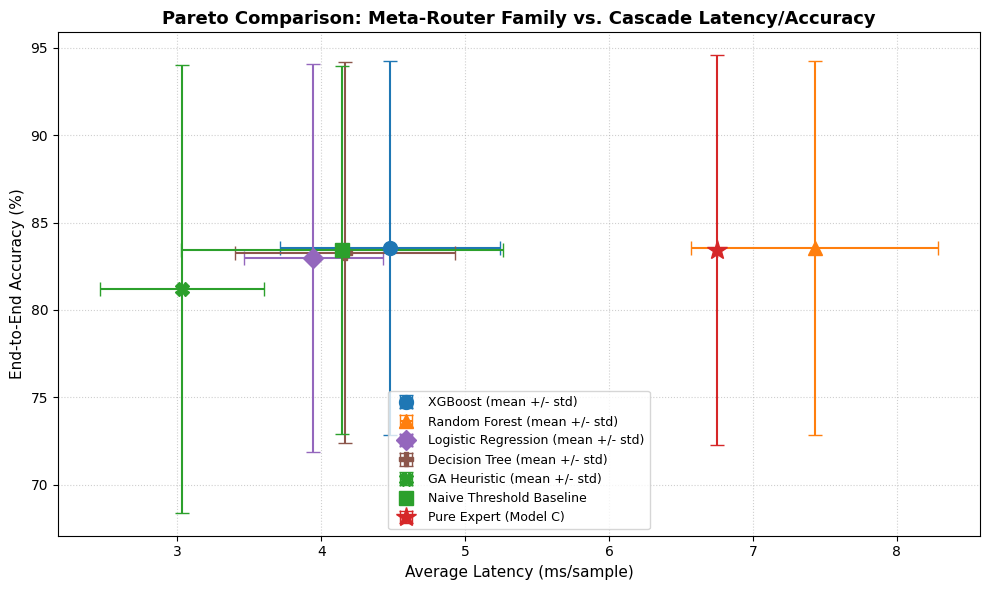

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

for name, spec in ROUTER_REGISTRY.items():
    ax.errorbar(trial_df[f'{name}_latency'].mean(), trial_df[f'{name}_accuracy'].mean(),
                xerr=trial_df[f'{name}_latency'].std(), yerr=trial_df[f'{name}_accuracy'].std(),
                fmt=spec['marker'], color=spec['color'], capsize=5, markersize=10,
                label=f"{spec['label']} (mean +/- std)")

ax.errorbar(trial_df['naive_latency'].mean(), trial_df['naive_accuracy'].mean(),
            xerr=trial_df['naive_latency'].std(), yerr=trial_df['naive_accuracy'].std(),
            fmt='s', color='tab:green', capsize=5, markersize=10, label='Naive Threshold Baseline')

ax.errorbar(trial_df['expert_latency'].mean(), trial_df['expert_accuracy'].mean(),
            xerr=0, yerr=trial_df['expert_accuracy'].std(),
            fmt='*', color='tab:red', capsize=5, markersize=15, label='Pure Expert (Model C)')

ax.set_xlabel('Average Latency (ms/sample)', fontsize=11)
ax.set_ylabel('End-to-End Accuracy (%)', fontsize=11)
ax.set_title('Pareto Comparison: Meta-Router Family vs. Cascade Latency/Accuracy', fontsize=13, fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.savefig('router_family_pareto.png', dpi=150)
plt.show()


## 10. Total Computation Time

Per-sample latency (above) measures production-time cost. This section reports the **total wall-clock compute time** for the experiment pipeline itself -- training + evaluating every router family, across all 8 seeds and both datasets -- which is a separate number your report should include alongside the per-sample figures.

In [13]:
print(f"Total pipeline wall-clock time (all datasets, all seeds, all routers): {TOTAL_PIPELINE_WALLCLOCK_SEC:.2f} s "
      f"({TOTAL_PIPELINE_WALLCLOCK_SEC/60:.2f} min)")
print()
print("--- Cumulative train+eval compute time per router family (all seeds x all datasets) ---")
for name, spec in ROUTER_REGISTRY.items():
    total_s = ROUTER_COMPUTE_TIME_SEC.get(name, float('nan'))
    share = 100 * total_s / sum(ROUTER_COMPUTE_TIME_SEC.values())
    print(f"{spec['label']:<20s} : {total_s:.2f} s  ({share:.1f}% of all router compute time)")


Total pipeline wall-clock time (all datasets, all seeds, all routers): 347.08 s (5.78 min)

--- Cumulative train+eval compute time per router family (all seeds x all datasets) ---
XGBoost              : 6.94 s  (9.8% of all router compute time)
Random Forest        : 54.25 s  (76.7% of all router compute time)
Logistic Regression  : 3.64 s  (5.2% of all router compute time)
Decision Tree        : 2.72 s  (3.9% of all router compute time)
GA Heuristic         : 3.16 s  (4.5% of all router compute time)


In [14]:
# Diagnostic: are XGBoost and RF making identical routing decisions on CIFAR-10,
# or just landing on the same aggregate accuracy by coincidence?
seed = 1
dataset_name = 'CIFAR-10'
torch.manual_seed(seed)
transform = DATASETS[dataset_name]['transform']
models = load_models_for_dataset(dataset_name)
val_dataset_current = get_dataset(dataset_name, transform)
idx = torch.randperm(len(val_dataset_current))[:N_SAMPLES_PER_SEED]
subset = torch.utils.data.Subset(val_dataset_current, idx)
loader = torch.utils.data.DataLoader(subset, batch_size=32, shuffle=False)

model_a, _, model_c = models
df = extract_telemetry(loader, model_a, model_c)
X = df[['confidence', 'entropy', 'margin']]
y = df['target_route']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
X_test_reset = X_test.reset_index(drop=True)

xgb_router = train_xgb_router(X_train, y_train, LATENCY_C, seed=seed)
rf_router = train_rf_router(X_train, y_train, LATENCY_C, seed=seed)

xgb_probs = xgb_router.predict_proba(X_test_reset)[:, 1]
rf_probs = rf_router.predict_proba(X_test_reset)[:, 1]
xgb_decisions = (xgb_probs >= CHOSEN_THETA).astype(int)
rf_decisions = (rf_probs >= CHOSEN_THETA).astype(int)

agreement = (xgb_decisions == rf_decisions).mean() * 100
print(f"XGBoost/RF decision agreement on {dataset_name}, seed {seed}: {agreement:.2f}%")
print(f"XGBoost escalation rate: {xgb_decisions.mean()*100:.2f}%")
print(f"RF escalation rate: {rf_decisions.mean()*100:.2f}%")

# Where they DO disagree, do the disagreements roughly cancel out in accuracy?
disagree_mask = xgb_decisions != rf_decisions
print(f"Samples where they disagree: {disagree_mask.sum()} / {len(disagree_mask)}")

raw_test = df.loc[X_test.index].reset_index(drop=True)
disagreement_rows = raw_test.loc[disagree_mask]
print((disagreement_rows['correct_a'] == disagreement_rows['correct_c']).mean())

Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master
Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master
Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


XGBoost/RF decision agreement on CIFAR-10, seed 1: 99.12%
XGBoost escalation rate: 15.12%
RF escalation rate: 15.00%
Samples where they disagree: 7 / 800
1.0
